# Ensemble Affinity Analysis (On-the-fly)

This notebook computes PRP and RA summaries in memory from merged benchmark files.

No summary CSVs are created and figures are shown inline only.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns

import sys
scripts_dir = (Path.cwd().resolve().parent / "scripts") if Path.cwd().name == "notebooks" else (Path.cwd().resolve() / "scripts")
if str(scripts_dir) not in sys.path:
    sys.path.append(str(scripts_dir))

from run_affinity_adjudication import (
    # compute_pair_stats,
    normalize_abstract_index,
    affinity_level_fixed,
 )


**Bucket definitions & pairing rules**
- **Bucket A (Within-level):** both abstracts have the same majority affinity level (e.g., both Moderate or both High).
- **Bucket B (Cross-boundary — Diagnostic):** one abstract majority = Moderate, the other = High.
- **Bucket C (Skip-level):** one abstract majority = Low, the other = High.

**Pair selection rules**
- Work per `RA2025_ID`. Consider only abstracts whose *ensemble* level is Moderate or High.
- Form all unordered pairs (i, j) within the same `RA2025_ID`.
- Keep pairs only if |ensemble_mean_i - ensemble_mean_j| >= 5 points.

**Per-model ranking & consensus**
- Per-model rank `rank_m(i,j)`: +1 if score_i > score_j, -1 if score_i < score_j, 0 if equal.
- Only count models that provided numeric scores for both abstracts; `n_models_pair` may vary by pair.
- `rank_consensus = abs(sum(rank_m)) / n_models_pair` (0 = split vote, 1 = unanimity). >0.67 ≈ 5/6 agreement.

**Majority label assignment**
- Apply `affinity_level_fixed(score)` per model (Low 0–40, Moderate 40–70, High 70–100).
- Majority label = most frequent per-model label; tie-breaker: choose higher level. Exclude unresolved cases.

**Diagnostics / expectations**
- Hypothesis A (coherent ranking): Bucket A ≈ Bucket B and both ≳ 0.7; Bucket C rare.
- Hypothesis B (boundary instability): Bucket A moderate, Bucket B ≈ 0.5, Bucket C frequent.

In [2]:
# Set run_id explicitly, or keep None to use latest run folder.
ignore_models = ['smollm2-1.7b', 'gemma3-4b', 'phi3-3.8b']
run_id =None
# run_id = "20260401_082538"
# run_id = "20260406_211752"
# run_id = "20260413_151017"
# run_id = "20260422_212121"
# run_id = "20260517_175302"
run_id = "20260422_212121_1"

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"

if run_id is None:
    run_dirs = sorted([p for p in bench_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No benchmark runs found under {bench_root}")
    run_dir = run_dirs[-1]
else:
    run_dir = bench_root / run_id

prp_path = run_dir / "merged_prp_affinities.csv"
ra_path = run_dir / "merged_ra_affinities.csv"

if not prp_path.exists() :
    raise FileNotFoundError(
        "Merged files not found. Run scripts/run_postprocessing.py first for this run_id."
    )
prp_df = pd.read_csv(prp_path)
prp_df = prp_df[~prp_df['Model_Slug'].isin(ignore_models)]

print("Run directory:", run_dir)
print("PRP rows:", len(prp_df), "| Models:", prp_df['Model_Slug'].nunique())
if ra_path.exists():
    ra_df = pd.read_csv(ra_path)
    ra_df = ra_df[~ra_df['Model_Slug'].isin(ignore_models)]
    print("RA rows:", len(ra_df), "| Models:", ra_df['Model_Slug'].nunique())


ra_df['Affinity_level'] = ra_df['LLM_Affinity'].apply(affinity_level_fixed)



Run directory: /mnt/c/Users/pigal/OneDrive - Imperial College London/PhD/Repositories/article-classifier/data/results/affinity_benchmark/20260422_212121_1
PRP rows: 3900 | Models: 6
RA rows: 28548 | Models: 6


In [3]:
# Intra-panel rank agreement analysis
from collections import Counter
import itertools
import os

# Ensure `ra_df` was loaded by previous cells
if 'ra_df' not in globals():
    raise RuntimeError("ra_df not found. Ensure merged_ra_affinities.csv was loaded above.")

# Prepare data
ra_df['LLM_Affinity'] = pd.to_numeric(ra_df['LLM_Affinity'], errors='coerce')
ra_df = ra_df.dropna(subset=['LLM_Affinity']).copy()
ra_df['Abstract_Index_Norm'] = ra_df['Abstract_Index'].apply(normalize_abstract_index)

# Ensemble mean per abstract (by RA question)
ensemble = (
    ra_df
    .groupby(['RA2025_ID','Abstract_Index_Norm','Document Title'], dropna=False, as_index=False)
    .agg(Affinity_Mean=('LLM_Affinity','mean'), N_Models=('LLM_Affinity','count'))
)
ensemble['Ensemble_Level'] = ensemble['Affinity_Mean'].apply(affinity_level_fixed)

# Merge ensemble info back to model rows (optional)
ra_with_ensemble = ra_df.merge(ensemble[['RA2025_ID','Abstract_Index_Norm','Affinity_Mean','Ensemble_Level']], on=['RA2025_ID','Abstract_Index_Norm'], how='left')

# Select abstracts whose ensemble-level is Moderate or High
sel = ensemble[ensemble['Ensemble_Level'].isin(['Moderate','High'])].copy()

out_rows = []
for ra_id, grp in sel.groupby('RA2025_ID'):
    abstracts = grp[['Abstract_Index_Norm','Affinity_Mean','Document Title']].drop_duplicates()
    abs_map = {r['Abstract_Index_Norm']:(r['Affinity_Mean'], r['Document Title']) for _,r in abstracts.iterrows()}
    abs_list = list(abs_map.keys())
    for a,b in itertools.combinations(abs_list,2):
        mean_a = abs_map[a][0]; mean_b = abs_map[b][0]
        mean_diff = abs(mean_a - mean_b)
        if mean_diff < 5:
            continue
        # per-model scores for this ra_id and abstracts a,b
        sub = ra_df[ra_df['RA2025_ID']==ra_id]
        piv = sub.pivot_table(index='Model_Slug', columns='Abstract_Index_Norm', values='LLM_Affinity', aggfunc='first')
        # require models that provided both scores
        if (a not in piv.columns) or (b not in piv.columns):
            continue
        models_both = piv.index[piv[a].notna() & piv[b].notna()]
        if len(models_both)==0:
            continue
        per_model_ranks = {}
        sum_rank = 0
        for m in models_both:
            sa = piv.at[m,a]; sb = piv.at[m,b]
            if sa > sb:
                r = 1
            elif sa < sb:
                r = -1
            else:
                r = 0
            per_model_ranks[m]=r
            sum_rank += r
        n_models_pair = len(models_both)
        rank_consensus = abs(sum_rank)/n_models_pair if n_models_pair>0 else None

        # majority labels per abstract (tie-breaker: higher level)
        def majority_label(abs_idx):
            sub2 = ra_df[(ra_df['RA2025_ID']==ra_id) & (ra_df['Abstract_Index_Norm']==abs_idx)]
            labels = sub2['LLM_Affinity'].apply(affinity_level_fixed).dropna().tolist()
            if not labels:
                return None
            counts = Counter(labels)
            most_common = counts.most_common()
            top_count = most_common[0][1]
            top_labels = [lab for lab,c in most_common if c==top_count]
            order = {'Low':0,'Moderate':1,'High':2}
            top_labels_sorted = sorted(top_labels, key=lambda x:order.get(x, -1), reverse=True)
            return top_labels_sorted[0]

        lab_a = majority_label(a)
        lab_b = majority_label(b)
        if lab_a is None or lab_b is None:
            bucket = None
        elif lab_a == lab_b:
            bucket = 'A'
        elif set([lab_a,lab_b])==set(['Moderate','High']):
            bucket = 'B'
        elif set([lab_a,lab_b])==set(['Low','High']):
            bucket = 'C'
        else:
            bucket = None

        out_rows.append({
            'RA2025_ID': ra_id,
            'abstract_i': a,
            'abstract_j': b,
            'title_i': abs_map[a][1],
            'title_j': abs_map[b][1],
            'mean_i': mean_a,
            'mean_j': mean_b,
            'mean_diff': mean_diff,
            'n_models_pair': n_models_pair,
            'rank_consensus': rank_consensus,
            'bucket': bucket,
            'per_model_ranks': per_model_ranks,
        })

out_df = pd.DataFrame(out_rows)
out_df = out_df.dropna(subset=['bucket']).copy()

agg = out_df.groupby('bucket').agg(counts=('rank_consensus','size'), mean_rank_consensus=('rank_consensus','mean')).reset_index()
print('Aggregated results:')
print(agg)

# Save outputs
out_dir = repo_root / 'notebooks' / 'outputs' / 'intra_panel_rank_agreement' / run_dir.name
out_dir.mkdir(parents=True, exist_ok=True)
out_df.to_csv(out_dir / 'pairwise_rank_consensus.csv', index=False)
agg.to_csv(out_dir / 'bucket_aggregate.csv', index=False)

# show some Bucket B examples for inspection
if 'display' in globals():
    try:
        display(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))
    except Exception:
        print(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))
else:
    print(out_df[out_df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10))

Aggregated results:
  bucket  counts  mean_rank_consensus
0      A    3249             0.549513
1      B    2722             0.754604
2      C    1061             0.744423
      RA2025_ID abstract_i abstract_j  \
7793         48         21         98   
7743         47         32          9   
7742         47         32         70   
7741         47         32          7   
7740         47         32          6   
7739         47         32         58   
7734         47         28         32   
7719         47         19         32   
97            3        100         56   
96            3        100         48   

                                                title_i  \
7793  Computational Performance Enhancement Strategi...   
7743  Ecological Robustness-Oriented Grid Network De...   
7742  Ecological Robustness-Oriented Grid Network De...   
7741  Ecological Robustness-Oriented Grid Network De...   
7740  Ecological Robustness-Oriented Grid Network De...   
7739  Ecological Robus

Total pairs: 7032


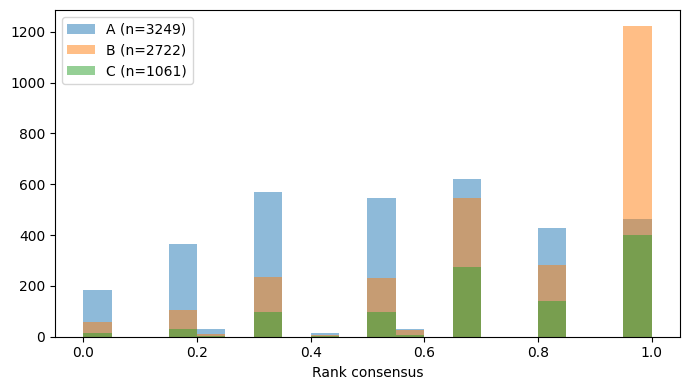

<Figure size 600x400 with 0 Axes>

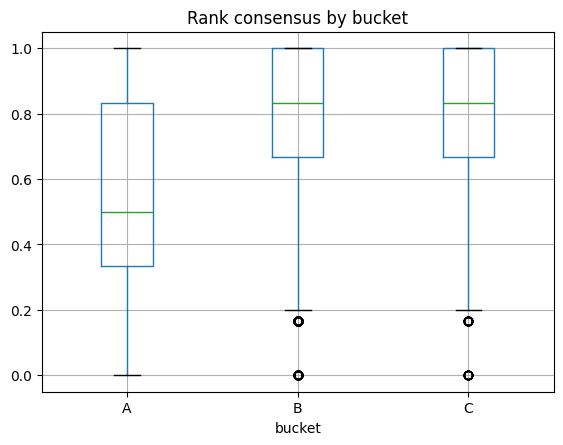

Bucket means:
A: 0.55
B: 0.75
C: 0.74


In [4]:
# Visualize bucket distributions and show example Bucket B pairs
import matplotlib.pyplot as plt
pair_csv = repo_root / 'notebooks' / 'outputs' / 'intra_panel_rank_agreement' / run_dir.name / 'pairwise_rank_consensus.csv'
df = pd.read_csv(pair_csv)
print('Total pairs:', len(df))

plt.figure(figsize=(7,4))
for b in ['A','B','C']:
    subset = df[df['bucket']==b]['rank_consensus']
    plt.hist(subset, bins=20, alpha=0.5, label=f'{b} (n={len(subset)})')
plt.xlabel('Rank consensus')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df_box = df[df['bucket'].isin(['A','B','C'])]
df_box.boxplot(column='rank_consensus', by='bucket')
plt.title('Rank consensus by bucket')
plt.suptitle('')
plt.show()

print('Bucket means:')
for b in ['A','B','C']:
    mean_val = df[df['bucket']==b]['rank_consensus'].mean()
    print(f'{b}: {mean_val:.2f}')
    
# print('\nTop Bucket B pairs:')
# topB = df[df['bucket']=='B'].sort_values('rank_consensus', ascending=False).head(10)
# print(topB[['RA2025_ID','abstract_i','abstract_j','mean_i','mean_j','mean_diff','n_models_pair','rank_consensus']])

/tmp/ipykernel_3058/176699278.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(unique_pairs, rotation=45)
/tmp/ipykernel_3058/176699278.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(unique_pairs, rotation=45)
/tmp/ipykernel_3058/176699278.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(unique_pairs, rotation=45)


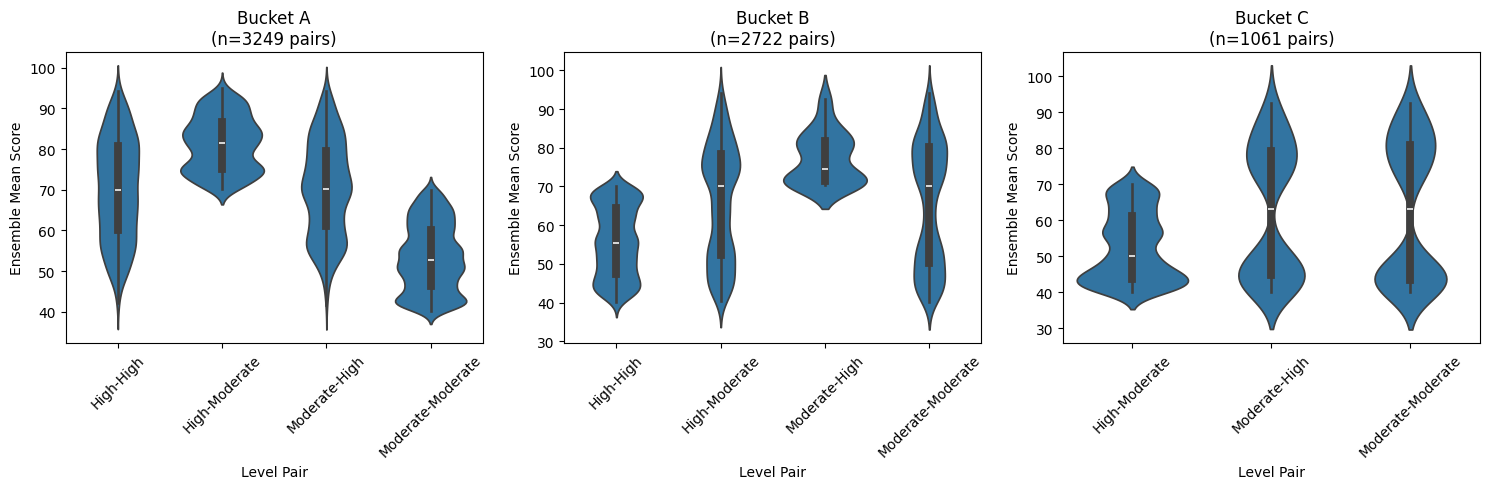

Score ranges by bucket and level:
  Bucket A, Level Pair High-High: n_pairs=287, score range=70.2–95.0, mean=81.3
  Bucket A, Level Pair High-Moderate: n_pairs=450, score range=41.7–94.2, mean=70.3
  Bucket A, Level Pair Moderate-High: n_pairs=425, score range=42.2–94.2, mean=70.1
  Bucket A, Level Pair Moderate-Moderate: n_pairs=2087, score range=40.2–70.0, mean=53.4
  Bucket B, Level Pair High-High: n_pairs=21, score range=70.5–92.5, mean=77.2
  Bucket B, Level Pair High-Moderate: n_pairs=822, score range=40.3–94.2, mean=66.1
  Bucket B, Level Pair Moderate-High: n_pairs=846, score range=40.2–94.2, mean=65.6
  Bucket B, Level Pair Moderate-Moderate: n_pairs=1033, score range=40.2–70.0, mean=55.9
  Bucket C, Level Pair High-Moderate: n_pairs=258, score range=40.2–92.7, mean=62.5
  Bucket C, Level Pair Moderate-High: n_pairs=326, score range=40.2–92.5, mean=62.6
  Bucket C, Level Pair Moderate-Moderate: n_pairs=477, score range=40.2–70.0, mean=52.6


In [5]:
# Score distribution by bucket and level combination
# import seaborn as sns

# # Reload data if needed
# if 'out_df' not in globals():
#     pair_csv = repo_root / 'notebooks'/'outputs' / 'intra_panel_rank_agreement' / run_dir.name / 'pairwise_rank_consensus.csv'
#     out_df = pd.read_csv(pair_csv)

# Compute ensemble levels for mean_i and mean_j
out_df['level_i'] = out_df['mean_i'].apply(affinity_level_fixed)
out_df['level_j'] = out_df['mean_j'].apply(affinity_level_fixed)
out_df['level_pair'] = out_df['level_i'] + '-' + out_df['level_j']

# Melt to get score distributions
df_melted = pd.concat([
    out_df[['bucket', 'level_pair', 'mean_i']].rename(columns={'mean_i': 'score'}),
    out_df[['bucket', 'level_pair', 'mean_j']].rename(columns={'mean_j': 'score'})
])

# Plot distributions for each bucket
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, bucket in enumerate(['A', 'B', 'C']):
    df_bucket = df_melted[df_melted['bucket'] == bucket]
    if len(df_bucket) == 0:
        axes[idx].text(0.5, 0.5, f'No data for Bucket {bucket}', ha='center', va='center')
        continue
    
    sns.violinplot(data=df_bucket, x='level_pair', y='score', ax=axes[idx], )
    axes[idx].set_title(f'Bucket {bucket}\n(n={len(out_df[out_df["bucket"]==bucket])} pairs)')
    axes[idx].set_xlabel('Level Pair')
    axes[idx].set_ylabel('Ensemble Mean Score')
    axes[idx].tick_params(axis='x', rotation=45)

        # Order x-axis labels
    unique_pairs = sorted(df_bucket['level_pair'].unique())
    axes[idx].set_xticklabels(unique_pairs, rotation=45)


plt.tight_layout()
plt.show()

# Print summary statistics
print('Score ranges by bucket and level:')
for bucket in ['A', 'B', 'C']:
    df_b = out_df[out_df['bucket'] == bucket]
    for lp in sorted(df_b['level_pair'].unique()):
        subset = df_b[df_b['level_pair'] == lp]
        scores = pd.concat([subset['mean_i'], subset['mean_j']])
        print(f"  Bucket {bucket}, Level Pair {lp}: n_pairs={len(subset)}, score range={scores.min():.1f}–{scores.max():.1f}, mean={scores.mean():.1f}")


In [6]:
# Summary statistics of df_melted by bucket and level_pair
agg = df_melted.groupby(['bucket','level_pair'])['score'].agg(
    n='count',
    min='min',
    q25=lambda s: s.quantile(0.25),
    median='median',
    mean='mean',
    q75=lambda s: s.quantile(0.75),
    max='max',
    std='std',
    n_unique=lambda s: s.nunique()
).reset_index()

modes_df = (
    df_melted
    .groupby(['bucket','level_pair'])['score']
    .apply(lambda s: pd.Series({
        'n_modes': len(s.mode()),
        'modes': s.mode().tolist(),
        'top_mode_freq': int(s.value_counts().iloc[0]) if not s.empty else 0,
        'top_2_values': "; ".join([f"{v}: {int(c)}" for v,c in s.value_counts().iloc[:2].items()]) if not s.empty else ''
    }))
    .reset_index()
)

df_stats = agg.merge(modes_df, on=['bucket','level_pair'], how='left').sort_values(['bucket','level_pair']).reset_index(drop=True)
df_stats.to_csv('prompt_modification.csv', index=False)

In [7]:


# Compute majority-vote level per abstract (tie -> choose higher level)
def maj_level_for_group(sub):
    labs = sub['LLM_Affinity'].apply(affinity_level_fixed).dropna().tolist()
    if not labs:
        return None
    counts = Counter(labs)
    top_count = max(counts.values())
    top_labels = [lab for lab,c in counts.items() if c==top_count]
    order = {'Low':0,'Moderate':1,'High':2}
    return sorted(top_labels, key=lambda x: order.get(x, -1), reverse=True)[0]

maj = (
    ra_with_ensemble
    .groupby(['RA2025_ID','Abstract_Index_Norm'])
    .apply(maj_level_for_group)
    .rename('majority_vote_level')
    .reset_index()
)

df = ra_with_ensemble.merge(maj, on=['RA2025_ID','Abstract_Index_Norm'], how='left')
df = df.rename(columns={'Model_Slug':'model_id', 'LLM_Affinity':'score', 'Affinity_Mean':'ensemble_mean'})
df = df[['model_id','score','majority_vote_level','ensemble_mean','RA2025_ID']]

# Exclude Low as requested
df_plot = df[df['majority_vote_level'] != 'Low'].copy()
if df_plot.empty:
    raise RuntimeError("No data after excluding 'Low' — check inputs.")

# Optional: only keep models with at least min_samples scores to avoid many empty facets
min_samples = 10
model_counts = df_plot.groupby('model_id')['score'].count()
good_models = model_counts[model_counts >= min_samples].index.tolist()
if len(good_models) == 0:
    # fallback: keep all models
    good_models = df_plot['model_id'].unique().tolist()
df_plot = df_plot[df_plot['model_id'].isin(good_models)]



/tmp/ipykernel_3058/2749726849.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(maj_level_for_group)


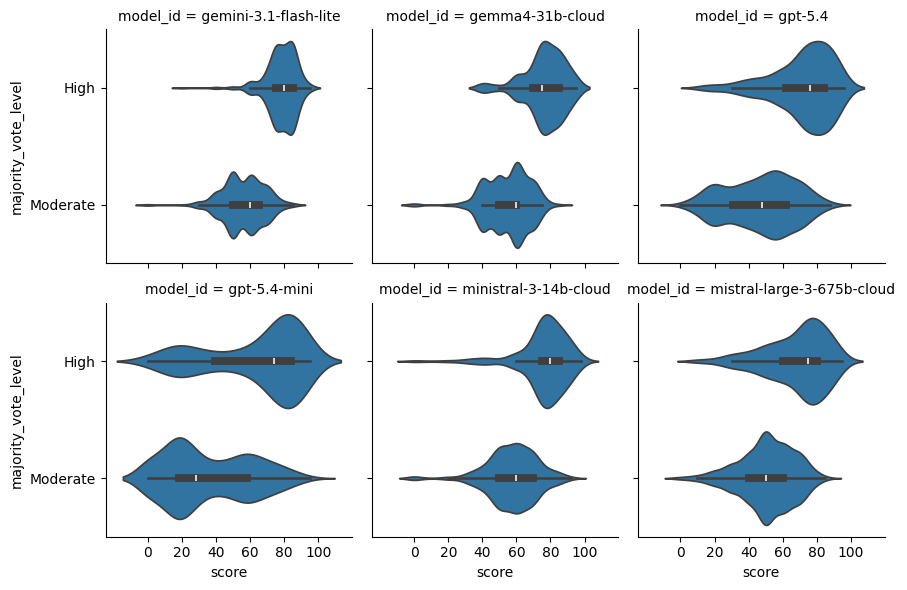

In [8]:

g = sns.catplot(
    df_plot,  # exclude low as before
    kind='violin',
    y='majority_vote_level',
    x='score',
    col='model_id',
    height=3,
    # aspect=2.8,
    col_wrap = 3,
    # col="majority_vote_level",
    # row="model_id",
    # height=2,
    # aspect=2.8,
)
g.set(xticks=np.arange(0,101,20))
plt.show()

In [9]:
out_df

,RA2025_ID,abstract_i,abstract_j,title_i,title_j,mean_i,mean_j,mean_diff,n_models_pair,rank_consensus,bucket,per_model_ranks,level_i,level_j,level_pair
0,1,100,17,Optimal Energy Utilization of MMC-HVDC System ...,Integrating Physical and Data-Driven System Fr...,66.666667,73.333333,6.666667,6,0.333333,A,"{'gemini-3.1-flash-lite': -1, 'gemma4-31b-clou...",Moderate,High,Moderate-High
1,1,100,19,Optimal Energy Utilization of MMC-HVDC System ...,Chance-Constrained Pre-Contingency Joint Self-...,66.666667,79.500000,12.833333,6,0.666667,A,"{'gemini-3.1-flash-lite': -1, 'gemma4-31b-clou...",Moderate,High,Moderate-High
2,1,100,39,Optimal Energy Utilization of MMC-HVDC System ...,AC/DC Hybrid Power System Damping Control Base...,66.666667,42.166667,24.500000,6,0.833333,B,"{'gemini-3.1-flash-lite': 1, 'gemma4-31b-cloud...",Moderate,Moderate,Moderate-Moderate
3,1,100,44,Optimal Energy Utilization of MMC-HVDC System ...,Hierarchical Control Strategy for Effective Vi...,66.666667,83.166667,16.500000,6,1.000000,A,"{'gemini-3.1-flash-lite': -1, 'gemma4-31b-clou...",Moderate,High,Moderate-High
4,1,100,52,Optimal Energy Utilization of MMC-HVDC System ...,Sparse Measurement-Based Modelling Low-Order D...,66.666667,76.833333,10.166667,6,0.666667,A,"{'gemini-3.1-flash-lite': 0, 'gemma4-31b-cloud...",Moderate,High,Moderate-High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7789,48,21,58,Computational Performance Enhancement Strategi...,Multi-Stage Decision Rules for Power Generatio...,60.500000,51.166667,9.333333,6,0.666667,C,"{'gemini-3.1-flash-lite': -1, 'gemma4-31b-clou...",Moderate,Moderate,Moderate-Moderate
7790,48,21,70,Computational Performance Enhancement Strategi...,Two-Stage Robust Unit Commitment Problem With ...,60.500000,41.666667,18.833333,6,0.833333,B,"{'gemini-3.1-flash-lite': 0, 'gemma4-31b-cloud...",Moderate,Moderate,Moderate-Moderate
7791,48,21,75,Computational Performance Enhancement Strategi...,Capacity Assessment for Wind-Storage Integrati...,60.500000,46.166667,14.333333,6,0.666667,B,"{'gemini-3.1-flash-lite': 1, 'gemma4-31b-cloud...",Moderate,Moderate,Moderate-Moderate
7792,48,21,79,Computational Performance Enhancement Strategi...,Probabilistic Forecasting-Based Reserve Determ...,60.500000,43.166667,17.333333,6,1.000000,B,"{'gemini-3.1-flash-lite': 1, 'gemma4-31b-cloud...",Moderate,Moderate,Moderate-Moderate


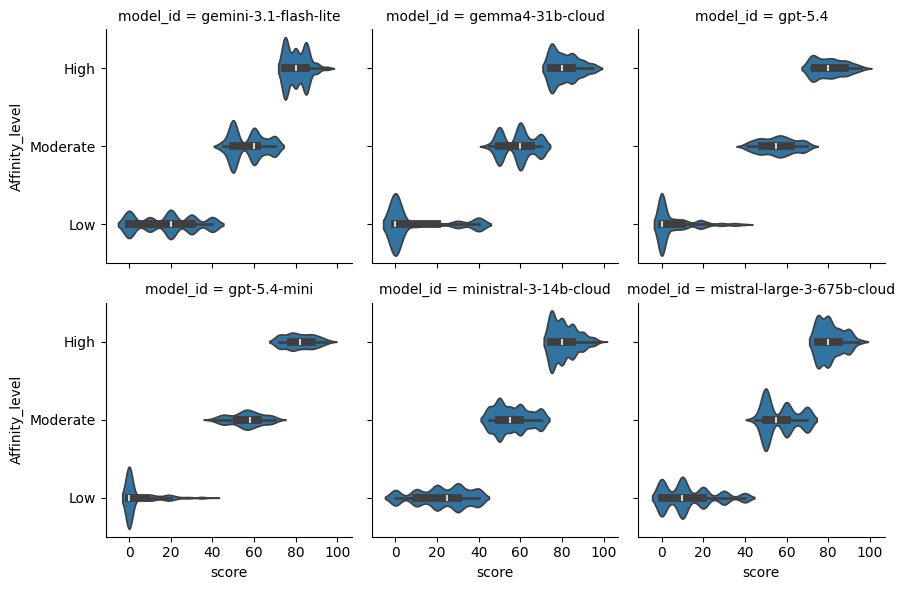

In [10]:
g = sns.catplot(
    data=ra_df[ra_df['Affinity_level'] != 'low'].rename(columns={'Model_Slug': 'model_id', 'LLM_Affinity': 'score'}),
    kind='violin',
    y='Affinity_level',
    x='score',
    col='model_id',
    height=3,
    col_wrap=3,
    order=['High', 'Moderate', 'Low'],
)
g.set(xticks=np.arange(0,101,20))
plt.show()